# LOGISTIC REGRESSION - EMAIL SPAM CLASSIFIER 

### Import libraries

In [2]:
import numpy as np
import pandas as pd

### Load Data

In [9]:
df = pd.read_csv("email_spam.csv", encoding="latin-1")
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


Checked whether null values are present

In [10]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

Dropped unnamed and empty columns that are unnecessary

In [12]:
df = df.drop(columns = ["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

In [16]:
pd.set_option("display.max_colwidth", None)

df.head(10)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"
5,spam,"FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv"
6,ham,Even my brother is not like to speak with me. They treat me like aids patent.
7,ham,As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune
8,spam,WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.
9,spam,Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Update Co FREE on 08002986030


In [17]:
df.shape

(5572, 2)

In [18]:
df["v1"].value_counts()

v1
ham     4825
spam     747
Name: count, dtype: int64

### Spam emails : 747   |   Non spam (ham) emails : 4825

In [21]:
df.describe()

,v1,v2
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


Renaming Columns

In [23]:
df = df.rename(columns = {"v1": "label", "v2": "email"})

In [35]:
df

,label,email
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"
...,...,...
5567,spam,"This is the 2nd time we have tried 2 contact u. U have won the å£750 Pound prize. 2 claim is easy, call 087187272008 NOW1! Only 10p per minute. BT-national-rate."
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other suggestions?"
5570,ham,The guy did some bitching but I acted like i'd be interested in buying something else next week and he gave it to us for free


Percentage Distribution of spam/non spam emails

In [28]:
df["label"].value_counts(normalize = True)

label
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64

Checking duplicate rows and removing them

In [29]:
df.duplicated().sum()

np.int64(403)

In [30]:
df = df.drop_duplicates()

In [32]:
df.duplicated().sum()

np.int64(0)

### Preprocessing

In [34]:
print("SPAM:")
print(df[df["label"] == "spam"]["email"].iloc[0])

print("\nHAM:")
print(df[df["label"] == "ham"]["email"].iloc[0])

SPAM:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

HAM:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...


1. Lowercase

In [39]:
df = df.copy()

In [40]:
df["email"] = df["email"].str.lower()

In [38]:
df["email"].head()

0                                                go until jurong point, crazy.. available only in bugis n great world la e buffet... cine there got amore wat...
1                                                                                                                                  ok lar... joking wif u oni...
2    free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005. text fa to 87121 to receive entry question(std txt rate)t&c's apply 08452810075over18's
3                                                                                                              u dun say so early hor... u c already then say...
4                                                                                                  nah i don't think he goes to usf, he lives around here though
Name: email, dtype: object

2. Punctuation

In [42]:
# Import Regular Expression
import re
df["email"] = df["email"].apply(lambda x: re.sub(r"[^\w\s]", "", x))

In [43]:
print(df["email"].iloc[0])

go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat


3. Extra whitespace

In [44]:
df["email"] = df["email"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

In [45]:
print(df["email"].iloc[0])

go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat


### TRAIN - TEST SPLIT

In [46]:
x = df["email"]
y = df["label"]

In [55]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

### TF-IDF

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

In [57]:
x_train_tfidf.shape

(4135, 8323)

In [58]:
x_test_tfidf.shape

(1034, 8323)

### Logistic regression

In [60]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(x_train_tfidf, y_train)

LogisticRegression()

In [65]:
y_pred = model.predict(x_test_tfidf)

In [66]:
print(y_pred[:10])

['ham' 'ham' 'ham' 'ham' 'ham' 'spam' 'ham' 'spam' 'ham' 'ham']


#### Accuracy

In [69]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9613152804642167


#### Classification Report (Precisoin, Recall, F1 score, Support)

In [70]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       889
        spam       0.97      0.74      0.84       145

    accuracy                           0.96      1034
   macro avg       0.97      0.87      0.91      1034
weighted avg       0.96      0.96      0.96      1034



### Confusion Matrix

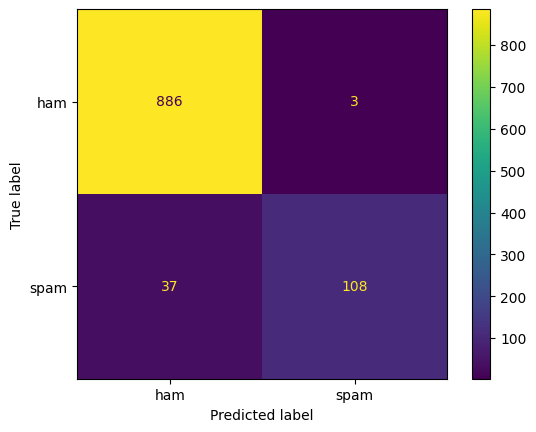

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred, labels = ["ham", "spam"])
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = ["ham","spam"]
)
disp.plot()
plt.show()

Spam Classifier ka first baseline model bana liya hai. ✅

### Error Analysis

In [74]:
error_analysis = x_test[
    (y_test == "spam") & (y_pred == "ham")
]

In [77]:
for email in error_analysis.head(10):
    print(email)
    print("-" * 150)

wow the boys r back take that 2007 uk tour win vip tickets prebook with vip club txt club to 81303 trackmarque ltd infovipclub4u
------------------------------------------------------------------------------------------------------------------------------------------------------
as a valued customer i am pleased to advise you that following recent review of your mob no you are awarded with a å1500 bonus prize call 09066364589
------------------------------------------------------------------------------------------------------------------------------------------------------
guess who am ithis is the first time i created a web page wwwasjesuscom read all i wrote im waiting for your opinions i want to be your friend 11
------------------------------------------------------------------------------------------------------------------------------------------------------
as a valued customer i am pleased to advise you that following recent review of your mob no you are awarded with a å1500 b

#### SAVE TF-IDF VECTORIZER AND MODEL

In [79]:
import joblib
joblib.dump(model, "spam_classifier.pkl")

['spam_classifier.pkl']

In [81]:
joblib.dump(vectorizer, "tfidfvectorizer.pkl")

['tfidfvectorizer.pkl']

In [82]:
test_email = "Congratulations you won a prize of 10000, spin the wheel to win more exciting prizes"

test_tfidf = vectorizer.transform([test_email])

print("Prediction:", model.predict(test_tfidf)[0])
print("Probabilities:", model.predict_proba(test_tfidf)[0])
print("Classes:", model.classes_)

Prediction: ham
Probabilities: [0.57125488 0.42874512]
Classes: ['ham' 'spam']


### Experimenting Class weighting (giving more importance to spam emails)

In [83]:
from sklearn.linear_model import LogisticRegression

balanced_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

balanced_model.fit(x_train_tfidf, y_train)

balanced_pred = balanced_model.predict(x_test_tfidf)

In [84]:
from sklearn.metrics import classification_report

print(classification_report(y_test, balanced_pred))

              precision    recall  f1-score   support

         ham       0.99      0.98      0.98       889
        spam       0.88      0.92      0.90       145

    accuracy                           0.97      1034
   macro avg       0.93      0.95      0.94      1034
weighted avg       0.97      0.97      0.97      1034



In [85]:
from sklearn.metrics import confusion_matrix

print("Original Model:")
print(confusion_matrix(y_test, y_pred, labels=["ham", "spam"]))

print("\nBalanced Model:")
print(confusion_matrix(y_test, balanced_pred, labels=["ham", "spam"]))

Original Model:
[[886   3]
 [ 37 108]]

Balanced Model:
[[871  18]
 [ 12 133]]


#### Introducing Bi gram to improve NLP (TF-IDF) to use work combinations

In [86]:
from sklearn.feature_extraction.text import TfidfVectorizer

bigram_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2)
)

x_train_bigram = bigram_vectorizer.fit_transform(x_train)
x_test_bigram = bigram_vectorizer.transform(x_test)

In [87]:
from sklearn.linear_model import LogisticRegression

bigram_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

bigram_model.fit(x_train_bigram, y_train)

bigram_pred = bigram_model.predict(x_test_bigram)

In [88]:
from sklearn.metrics import classification_report

print(classification_report(y_test, bigram_pred))

              precision    recall  f1-score   support

         ham       0.99      0.98      0.98       889
        spam       0.89      0.92      0.91       145

    accuracy                           0.97      1034
   macro avg       0.94      0.95      0.95      1034
weighted avg       0.97      0.97      0.97      1034



In [89]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(
    y_test,
    bigram_pred,
    labels=["ham", "spam"]
))

[[873  16]
 [ 11 134]]


#### Now using hyperparatmer tuning, by using logistic regression c = 0.1, 1, 10

In [90]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

c_values = [0.1, 1.0, 10.0]

for c in c_values:
    model_c = LogisticRegression(
        C=c,
        class_weight="balanced",
        max_iter=1000
    )

    model_c.fit(x_train_bigram, y_train)
    pred_c = model_c.predict(x_test_bigram)

    print(f"\nC = {c}")
    print(classification_report(y_test, pred_c))



C = 0.1
              precision    recall  f1-score   support

         ham       0.99      0.98      0.98       889
        spam       0.86      0.91      0.89       145

    accuracy                           0.97      1034
   macro avg       0.92      0.94      0.93      1034
weighted avg       0.97      0.97      0.97      1034


C = 1.0
              precision    recall  f1-score   support

         ham       0.99      0.98      0.98       889
        spam       0.89      0.92      0.91       145

    accuracy                           0.97      1034
   macro avg       0.94      0.95      0.95      1034
weighted avg       0.97      0.97      0.97      1034


C = 10.0
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       889
        spam       0.92      0.92      0.92       145

    accuracy                           0.98      1034
   macro avg       0.96      0.96      0.96      1034
weighted avg       0.98      0.98      0.98   

In [92]:

from sklearn.model_selection import train_test_split

x_train_new, x_val, y_train_new, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Training:", x_train_new.shape)
print("Validation:", x_val.shape)
print("Final test:", x_test.shape)


Training: (3308,)
Validation: (827,)
Final test: (1034,)


In [93]:
from sklearn.feature_extraction.text import TfidfVectorizer

final_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2)
)

x_train_new_tfidf = final_vectorizer.fit_transform(x_train_new)
x_val_tfidf = final_vectorizer.transform(x_val)

### Training Logistic regression with improved model

In [94]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

final_model = LogisticRegression(
    C=10.0,
    class_weight="balanced",
    max_iter=1000
)

final_model.fit(x_train_new_tfidf, y_train_new)

val_pred = final_model.predict(x_val_tfidf)

print(classification_report(y_val, val_pred))

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       725
        spam       0.92      0.90      0.91       102

    accuracy                           0.98       827
   macro avg       0.95      0.95      0.95       827
weighted avg       0.98      0.98      0.98       827



In [95]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

final_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2)
)

x_train_full_tfidf = final_vectorizer.fit_transform(x_train)
x_test_final_tfidf = final_vectorizer.transform(x_test)

final_model = LogisticRegression(
    C=10.0,
    class_weight="balanced",
    max_iter=1000
)

final_model.fit(x_train_full_tfidf, y_train)

LogisticRegression(C=10.0, class_weight='balanced', max_iter=1000)

In [96]:
from sklearn.metrics import classification_report

y_test_final_pred = final_model.predict(x_test_final_tfidf)

print(classification_report(y_test, y_test_final_pred))

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       889
        spam       0.92      0.92      0.92       145

    accuracy                           0.98      1034
   macro avg       0.96      0.96      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [98]:
import joblib

joblib.dump(final_model, "spam_model_v2.pkl")
joblib.dump(final_vectorizer, "tfidf_vectorizer_v2.pkl")

['tfidf_vectorizer_v2.pkl']